# Install libraries

In [ ]:
%%capture
!pip install scikit-learn seaborn pandas matplotlib numpy

#Decision Tree

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from google.colab import drive
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data
data = pd.read_csv('/content/drive/MyDrive/University/Graduate/Classes/3.semester/AI design/Assignment/Ames_Housing_Sales.csv')

In [ ]:
data

,1stFlrSF,2ndFlrSF,3SsnPorch,Alley,BedroomAbvGr,BldgType,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,...,ScreenPorch,Street,TotRmsAbvGrd,TotalBsmtSF,Utilities,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold,SalePrice
0,856.0,854.0,0.0,None,3,1Fam,TA,No,706.0,0.0,...,0.0,Pave,8,856.0,AllPub,0.0,2003,2003,2008,208500.0
1,1262.0,0.0,0.0,None,3,1Fam,TA,Gd,978.0,0.0,...,0.0,Pave,6,1262.0,AllPub,298.0,1976,1976,2007,181500.0
2,920.0,866.0,0.0,None,3,1Fam,TA,Mn,486.0,0.0,...,0.0,Pave,6,920.0,AllPub,0.0,2001,2002,2008,223500.0
3,961.0,756.0,0.0,None,3,1Fam,Gd,No,216.0,0.0,...,0.0,Pave,7,756.0,AllPub,0.0,1915,1970,2006,140000.0
4,1145.0,1053.0,0.0,None,4,1Fam,TA,Av,655.0,0.0,...,0.0,Pave,9,1145.0,AllPub,192.0,2000,2000,2008,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,953.0,694.0,0.0,None,3,1Fam,None,None,0.0,0.0,...,0.0,Pave,7,953.0,AllPub,0.0,1999,2000,2007,175000.0
1375,2073.0,0.0,0.0,None,3,1Fam,TA,No,790.0,163.0,...,0.0,Pave,7,1542.0,AllPub,349.0,1978,1988,2010,210000.0
1376,1188.0,1152.0,0.0,None,4,1Fam,Gd,No,275.0,0.0,...,0.0,Pave,9,1152.0,AllPub,0.0,1941,2006,2010,266500.0
1377,1078.0,0.0,0.0,None,2,1Fam,TA,Mn,49.0,1029.0,...,0.0,Pave,5,1078.0,AllPub,366.0,1950,1996,2010,142125.0


In [ ]:
print(data.columns)

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'Alley', 'BedroomAbvGr',
       'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtFinType1', 'BsmtFinType2', 'BsmtFullBath', 'BsmtHalfBath',
       'BsmtQual', 'BsmtUnfSF', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'EnclosedPorch', 'ExterCond', 'ExterQual', 'Exterior1st',
       'Exterior2nd', 'Fence', 'FireplaceQu', 'Fireplaces', 'Foundation',
       'FullBath', 'Functional', 'GarageArea', 'GarageCars', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'GarageYrBlt', 'GrLivArea',
       'HalfBath', 'Heating', 'HeatingQC', 'HouseStyle', 'KitchenAbvGr',
       'KitchenQual', 'LandContour', 'LandSlope', 'LotArea', 'LotConfig',
       'LotFrontage', 'LotShape', 'LowQualFinSF', 'MSSubClass', 'MSZoning',
       'MasVnrArea', 'MasVnrType', 'MiscFeature', 'MiscVal', 'MoSold',
       'Neighborhood', 'OpenPorchSF', 'OverallCond', 'OverallQual',
       'PavedDrive', 'PoolArea', 'PoolQC',

In [ ]:
categorical_columns = data.select_dtypes(include=['object']).columns

In [ ]:
data.isna()

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Grvl,Street_Pave,Utilities_AllPub,Utilities_NoSeWa
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1374,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1375,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1376,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1377,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
data = pd.get_dummies(data, columns=categorical_columns)

In [ ]:
X = data.drop(columns=['SalePrice'])
y = data['SalePrice']

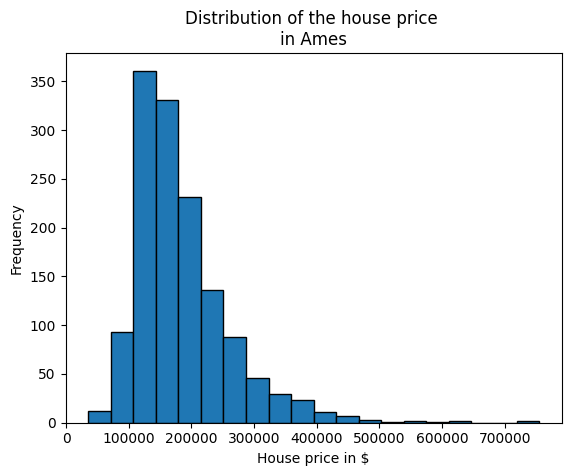

In [ ]:
import matplotlib.pyplot as plt
y.plot.hist(bins=20, edgecolor="black")
plt.xlabel("House price in $")
_ = plt.title("Distribution of the house price \nin Ames")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
initial_model = DecisionTreeRegressor(random_state=42)
initial_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred = initial_model.predict(X_test)

In [ ]:
import numpy as np
def custom_accuracy(y_true, y_pred, threshold):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true) < threshold)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 1877324038.1231885
R-squared: 0.6849476005443802
Custom Accuracy: 51.81159420289855 %


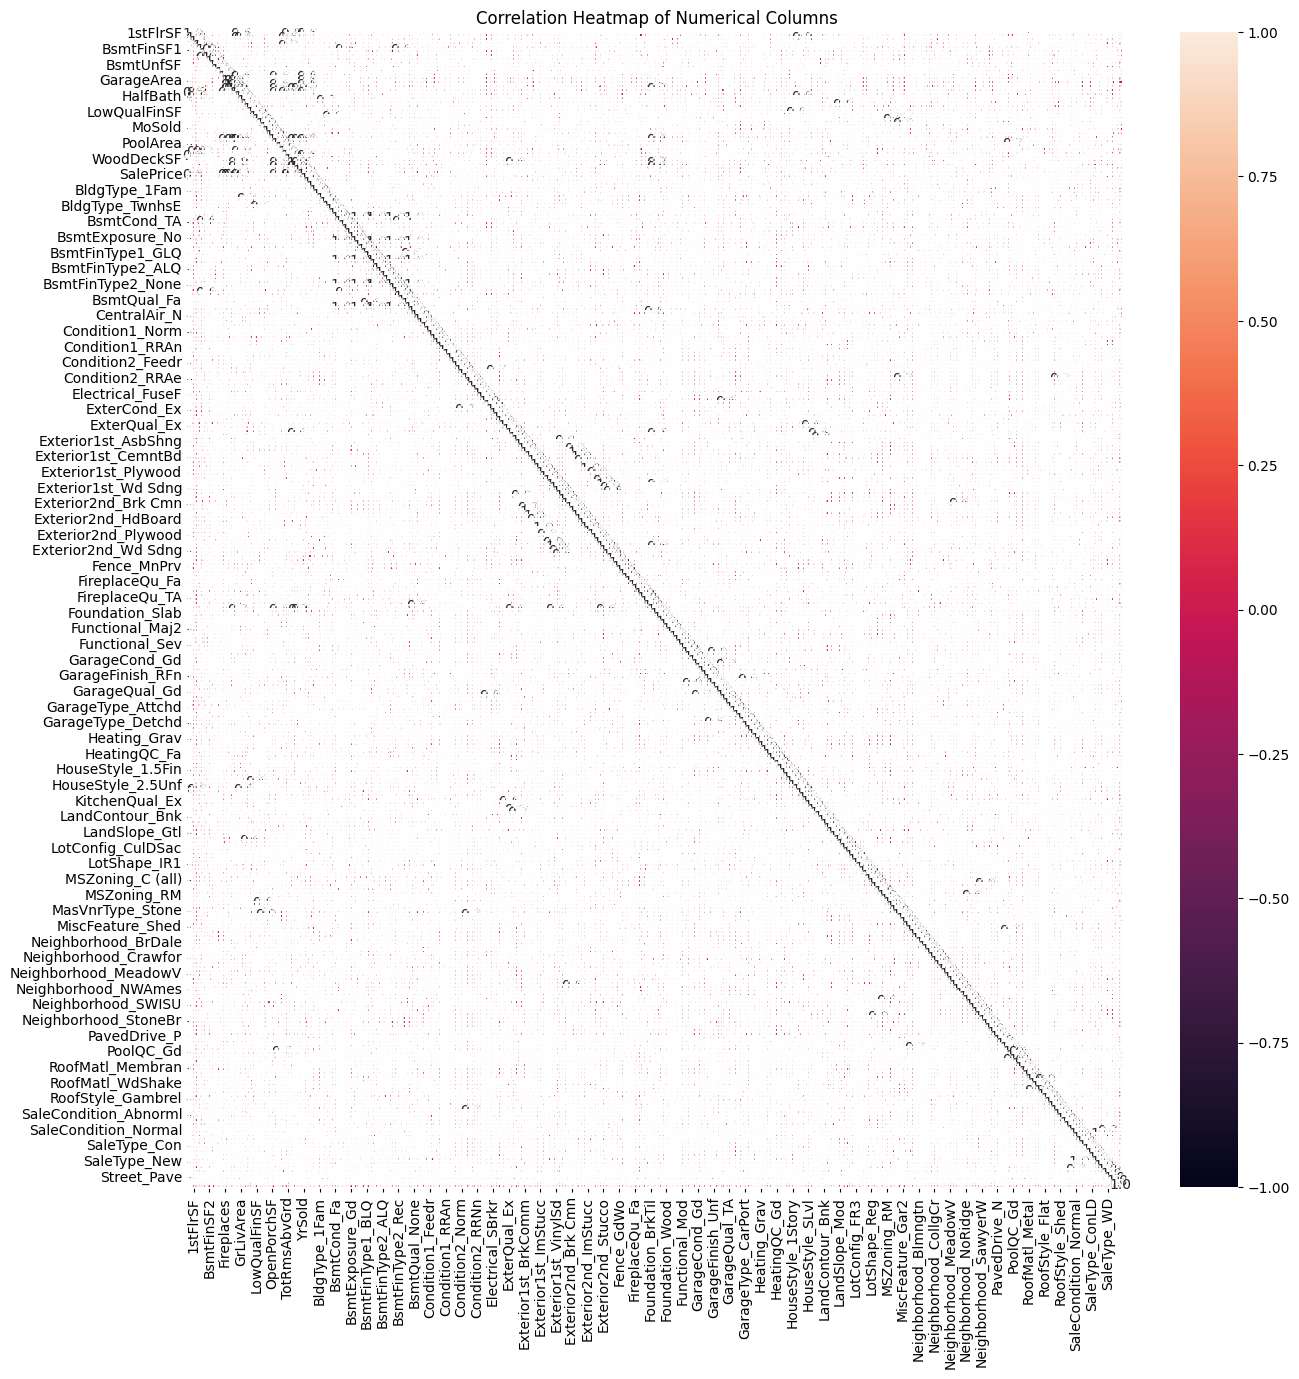

In [ ]:
plt.figure(figsize=(15, 15))
sns.heatmap(data.corr(), annot=True, fmt=".1f")
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

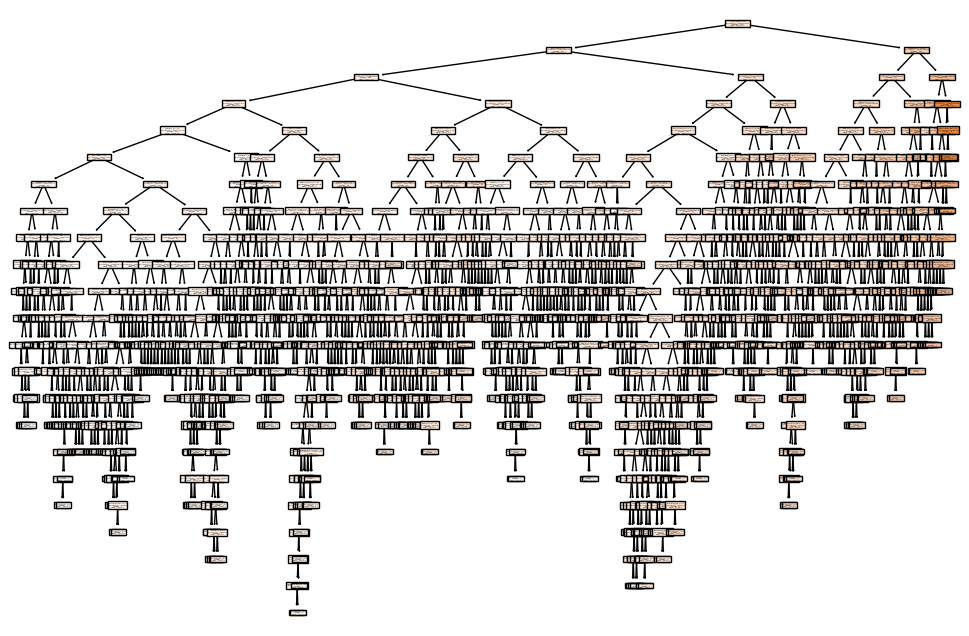

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

# Hyperparameter tuning

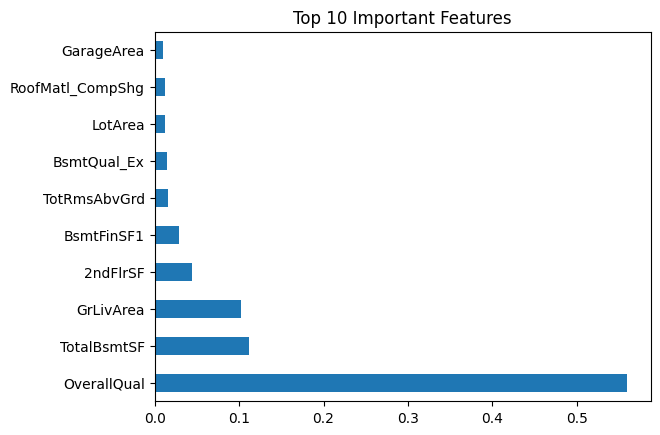

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

## Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'max_depth': [10, 20, 30, 40, 50, 60, None],
    'min_samples_split': [2, 5, 10, 15, 20, 25],
    'min_samples_leaf': [1, 2, 4, 5, 6, 7, 8],
    'max_features': ['auto', 'sqrt']
}

In [ ]:
grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 588 candidates, totalling 2940 fits


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, 40, 50, 60, None],
                         'max_features': ['auto', 'sqrt'],
                         'min_samples_leaf': [1, 2, 4, 5, 6, 7, 8],
                         'min_samples_split': [2, 5, 10, 15, 20, 25]},
             verbose=2)

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 2043584339.2012722
R-squared: 0.6570458075000475
Custom Accuracy: 49.275362318840585 %


## Random Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_dist = {
    'max_depth': [10, 20, 30, 40, 50,  60, None],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 10, 11, 12, 13,14, 15],
    'min_samples_leaf': [1, 2, 4, 5,6],
    'max_features': ['auto', 'sqrt']
}

In [ ]:
random_search = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), param_distributions=param_dist,
                                   n_iter=100, cv=5, verbose=2, random_state=42, n_jobs=-1)

In [ ]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 60,
                                                      None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4, 5, 6],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              10, 11, 12, 13,
                                                              14, 15]},
                   random_state=42, verbose=2)

In [ ]:
best_model = random_search.best_estimator_

In [ ]:
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 1961430220.2516243
R-squared: 0.6708329064635938
Custom Accuracy: 53.985507246376805 %


## Bayesian optimization

In [ ]:
!pip install bayesian-optimization

In [ ]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score

In [ ]:
def dtree_cv(max_depth, min_samples_split, min_samples_leaf, max_features):
    estimator = DecisionTreeRegressor(
        max_depth=int(max_depth),
        min_samples_split=int(min_samples_split),
        min_samples_leaf=int(min_samples_leaf),
        max_features=max_features
    )
    cval = cross_val_score(estimator, X, y, scoring='neg_mean_squared_error', cv=5)
    return cval.mean()

In [ ]:
params = {
    'max_depth': (10, 90),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10),
    'max_features': (0.1, 1)
}

In [ ]:
optimizer = BayesianOptimization(
    f=dtree_cv,
    pbounds=params,
    random_state=42,
)

In [ ]:
optimizer.maximize(init_points=10, n_iter=100)

|   iter    |  target   | max_depth | max_fe... | min_sa... | min_sa... |
-------------------------------------------------------------------------
| 1         | -1.718e+0 | 39.96     | 0.9556    | 7.588     | 12.78     |
| 2         | -1.835e+0 | 22.48     | 0.2404    | 1.523     | 17.59     |
| 3         | -1.806e+0 | 58.09     | 0.7373    | 1.185     | 19.46     |
| 4         | -1.718e+0 | 76.6      | 0.2911    | 2.636     | 5.301     |
| 5         | -1.639e+0 | 34.34     | 0.5723    | 4.888     | 7.242     |
| 6         | -2.182e+0 | 58.95     | 0.2255    | 3.629     | 8.595     |
| 7         | -1.792e+0 | 46.49     | 0.8067    | 2.797     | 11.26     |
| 8         | -2.07e+09 | 57.39     | 0.1418    | 6.468     | 5.069     |
| 9         | -1.43e+09 | 15.2      | 0.954     | 9.691     | 16.55     |
| 10        | -1.888e+0 | 34.37     | 0.1879    | 7.158     | 9.923     |
| 11        | -1.491e+0 | 11.73     | 1.0       | 10.0      | 16.11     |
| 12        | -1.492e+0 | 15.31     | 

In [ ]:
params_best = optimizer.max['params']
print('Best Parameters:', params_best)

Best Parameters: {'max_depth': 15.663341578046461, 'max_features': 0.6354110838851513, 'min_samples_leaf': 9.416181828742667, 'min_samples_split': 12.820660824509867}


In [ ]:
best_model = DecisionTreeRegressor(
    max_depth=int(params_best['max_depth']),
    min_samples_split=int(params_best['min_samples_split']),
    min_samples_leaf=int(params_best['min_samples_leaf']),
    max_features=params_best['max_features']
)
best_model.fit(X, y)

DecisionTreeRegressor(max_depth=15, max_features=0.6354110838851513,
                      min_samples_leaf=9, min_samples_split=12)

In [ ]:
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)


print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 859024511.6647154
R-squared: 0.8558385616466486
Custom Accuracy: 72.82608695652173 %


## Optuna

In [ ]:
!pip install optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.6/409.6 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.8/226.8 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 7.3 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_uniform('max_features', 0.1, 1.0)

    regressor = DecisionTreeRegressor(max_depth=max_depth,
                                      min_samples_split=min_samples_split,
                                      min_samples_leaf=min_samples_leaf,
                                      max_features=max_features)

    score = cross_val_score(regressor, X, y, n_jobs=-1, cv=3)
    return score.mean()

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

[I 2023-11-21 09:41:48,121] A new study created in memory with name: no-name-4f3cb193-0ad2-42bb-9307-6179b0e2a9d9
<ipython-input-141-907fdb6b7a18>:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  max_features = trial.suggest_uniform('max_features', 0.1, 1.0)
[I 2023-11-21 09:41:48,208] Trial 0 finished with value: 0.6048627901102385 and parameters: {'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.20346486989117274}. Best is trial 0 with value: 0.6048627901102385.
[I 2023-11-21 09:41:48,313] Trial 1 finished with value: 0.6642251984682597 and parameters: {'max_depth': 36, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 0.4698709769676047}. Best is trial 1 with value: 0.6642251984682597.
[I 2023-11-21 09:41:48,426] Trial 2 finished with value: 0.7408767994484834 and parameters: {'max_depth': 21, 'mi

In [ ]:
params_best = study.best_params
print('Best Parameters:', params_best)

Best Parameters: {'max_depth': 39, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.7583563094203387}


In [ ]:
best_model = DecisionTreeRegressor(**params_best)
best_model.fit(X, y)

DecisionTreeRegressor(max_depth=39, max_features=0.7583563094203387,
                      min_samples_leaf=2, min_samples_split=10)

In [ ]:
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)


print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 234293936.51556557
R-squared: 0.9606808066278604
Custom Accuracy: 89.13043478260869 %


In [ ]:
def objective(trial):
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_uniform('max_features', 0.1, 1.0)

    regressor = DecisionTreeRegressor(max_depth=max_depth,
                                      min_samples_split=min_samples_split,
                                      min_samples_leaf=min_samples_leaf,
                                      max_features=max_features)

    mse = -cross_val_score(regressor, X, y, n_jobs=-1, cv=3, scoring='neg_mean_squared_error').mean()
    return mse


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)


params_best = study.best_params
print('Best Parameters:', params_best)

best_model = DecisionTreeRegressor(**params_best)
best_model.fit(X, y)

[I 2023-11-21 09:43:28,508] A new study created in memory with name: no-name-90285792-7e2f-4d52-afa9-14356c015ab1
<ipython-input-150-c7fa7c062531>:6: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  max_features = trial.suggest_uniform('max_features', 0.1, 1.0)
[I 2023-11-21 09:43:28,646] Trial 0 finished with value: 1979985194.9050465 and parameters: {'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 0.5208583941285179}. Best is trial 0 with value: 1979985194.9050465.
[I 2023-11-21 09:43:28,785] Trial 1 finished with value: 1890269507.0802317 and parameters: {'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.7268688354858773}. Best is trial 1 with value: 1890269507.0802317.
[I 2023-11-21 09:43:28,897] Trial 2 finished with value: 1856725895.1417472 and parameters: {'max_depth': 34, 'min

Best Parameters: {'max_depth': 47, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.8569842853770341}


DecisionTreeRegressor(max_depth=47, max_features=0.8569842853770341,
                      min_samples_leaf=2, min_samples_split=9)

In [ ]:
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
custom_acc = custom_accuracy(y_test, y_pred, threshold=0.1)


print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Custom Accuracy: {custom_acc*100} %')

Mean Squared Error: 241148104.87671265
R-squared: 0.9595305405338882
Custom Accuracy: 89.85507246376811 %
